# MNIST Digit GAN

# Import Libraries

In [1]:
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import vstack
from numpy.random import randn
from numpy.random import randint
from keras.datasets.mnist import load_data
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Reshape
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Dropout
from matplotlib import pyplot

2025-07-26 16:33:33.291396: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-26 16:33:33.363685: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/kevin-lin/anaconda3/envs/data-science-ml/lib/python3.10/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


# Prepare Dataset   

Load the MNIST dataset.

In [2]:
def load_real_samples():
	# Load MNIST data
	(trainX, trainY), (testX, testY) = load_data()
	# Add channel dimension for grayscale images
	X = expand_dims(trainX, axis=-1)
	# Convert to float and normalize to [0,1] range
	X = X.astype('float32')
	X = X / 255.0
	return X

def generate_real_samples(dataset, n_samples):
	# Select random samples from the dataset
	ix = randint(0, dataset.shape[0], n_samples)
	X = dataset[ix]
	# Create labels of 1 for real images
	y = ones((n_samples, 1))
	return X, y

In [4]:
test = load_real_samples()
# Print shape of the dataset
print('Loaded', test.shape[0], 'images with shape', test.shape[1:], test.shape[2], test.shape[3])

Loaded 60000 images with shape (28, 28, 1) 28 1


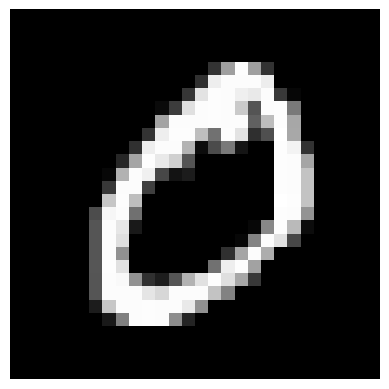

In [8]:
# Draw and display a sample image
def draw_sample_image(sample):
    # Reshape the sample to 28x28x1
    sample = sample.reshape((28, 28))
    # Plot the image
    pyplot.imshow(sample, cmap='gray')
    pyplot.axis('off')
    pyplot.show()
draw_sample_image(test[1])

Generate fake dataset.

In [ ]:
def generate_latent_points(latent_dim, n_samples):
	# Generate random noise from normal distribution
	x_input = randn(latent_dim * n_samples)
	# Reshape to (n_samples, latent_dim)
	x_input = x_input.reshape(n_samples, latent_dim)
	return x_input

def generate_fake_samples(g_model, latent_dim, n_samples):
	# Generate random noise points
	x_input = generate_latent_points(latent_dim, n_samples)
	# Use generator to create fake images
	X = g_model.predict(x_input)
	# Create labels of 0 for fake images
	y = zeros((n_samples, 1))
	return X, y

# Define Discriminator & Generator

In [ ]:
# Discriminator
def define_discriminator(in_shape=(28,28,1)):
	model = Sequential()
	# First convolutional layer with 64 filters, 3x3 kernel, stride 2
	model.add(Conv2D(64, (3,3), strides=(2, 2), padding='same', input_shape=in_shape))
	model.add(LeakyReLU(alpha=0.2))
	model.add(Dropout(0.4))
	# Second convolutional layer with 64 filters, 3x3 kernel, stride 2
	model.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
	model.add(LeakyReLU(alpha=0.2))
	model.add(Dropout(0.4))
	# Flatten and output a single probability (real vs fake)
	model.add(Flatten())
	model.add(Dense(1, activation='sigmoid'))
	# Compile the model with Adam optimizer
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
	return model

In [ ]:
# Generator
def define_generator(latent_dim):
	model = Sequential()
	# Calculate number of nodes for reshaping (7x7x128)
	n_nodes = 128 * 7 * 7
	# Dense layer to transform noise vector into feature map
	model.add(Dense(n_nodes, input_dim=latent_dim))
	model.add(LeakyReLU(alpha=0.2))
	# Reshape to 7x7x128 feature map
	model.add(Reshape((7, 7, 128)))
	# First upsampling: 7x7 -> 14x14
	model.add(Conv2DTranspose(128, (5,5), strides=(2,2), padding='same'))
	model.add(LeakyReLU(alpha=0.2))
	# Second upsampling: 14x14 -> 28x28
	model.add(Conv2DTranspose(128, (5,5), strides=(2,2), padding='same'))
	model.add(LeakyReLU(alpha=0.2))
	# Final layer to generate single-channel image (28x28x1)
	model.add(Conv2D(1, (7,7), activation='sigmoid', padding='same'))
	return model

# Training

- Train for 200 epochs
- Save loss after every epoch
- Examine Generator output at 1st, 50th, 100th, 150th and 200th epochs

In [ ]:
def save_plot(examples, epoch, n=10):
	# Create a grid of n x n images
	for i in range(n * n):
		pyplot.subplot(n, n, 1 + i)
		pyplot.axis('off')
		# Display image in grayscale
		pyplot.imshow(examples[i, :, :, 0], cmap='gray_r')
	# Save the plot with epoch number in filename
	filename = 'generated_plot_e%03d.png' % (epoch+1)
	pyplot.savefig(filename)
	pyplot.close()

# Evaluate and save model performance
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=100):
	# Test discriminator on real samples
	X_real, y_real = generate_real_samples(dataset, n_samples)
	_, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
	# Test discriminator on fake samples
	x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
	_, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
	# Print accuracy scores
	print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))
	# Save generated images and model
	save_plot(x_fake, epoch)
	filename = 'generator_model_%03d.h5' % (epoch + 1)
	g_model.save(filename)

In [ ]:
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=200, n_batch=256):
	# Calculate number of batches per epoch
	bat_per_epo = int(dataset.shape[0] / n_batch)
	half_batch = int(n_batch / 2)
	
	# Train for specified number of epochs
	for i in range(n_epochs):
		# Train on each batch
		for j in range(bat_per_epo):
			# Get real and fake samples
			X_real, y_real = generate_real_samples(dataset, half_batch)
			X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			# Combine real and fake samples
			X, y = vstack((X_real, X_fake)), vstack((y_real, y_fake))
			# Train discriminator on combined batch
			d_loss, _ = d_model.train_on_batch(X, y)
			
			# Train generator via the GAN model
			X_gan = generate_latent_points(latent_dim, n_batch)
			y_gan = ones((n_batch, 1))  # Generator wants discriminator to classify as real
			g_loss = gan_model.train_on_batch(X_gan, y_gan)
			
			# Print progress
			print('>%d, %d/%d, d=%.3f, g=%.3f' % (i+1, j+1, bat_per_epo, d_loss, g_loss))
		
		# Save progress every 10 epochs
		if (i+1) % 10 == 0:
			summarize_performance(i, g_model, d_model, dataset, latent_dim)

# Plots & Graphs